# Conditional Graph (Logic In the Graph)

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int


In [4]:
def adder(state: AgentState) -> AgentState:
    """Adds two numbers."""
    state['finalNumber'] = state['number1'] + state['number2']

def subtractor(state: AgentState) -> AgentState:
    """Subtracts two numbers."""
    state['finalNumber'] = state['number1'] - state['number2']

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph."""
    if state['operation'] == '+':
        return "addition_operation"
    elif state['operation'] == '-':
        return "subtraction_operation"

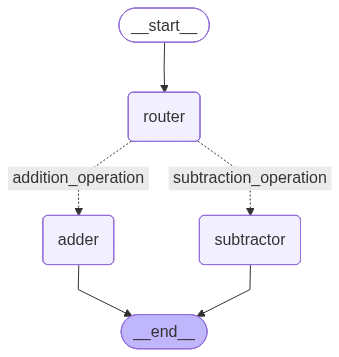

In [6]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder)
graph.add_node("subtractor", subtractor)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge: Node
        "addition_operation": "adder",
        "subtraction_operation": "subtractor",
    }
)

graph.add_edge("adder", END)
graph.add_edge("subtractor", END)

app = graph.compile()
app

